Test 1 — Number of trees for n = 4
Generated: 6
Expected : 6



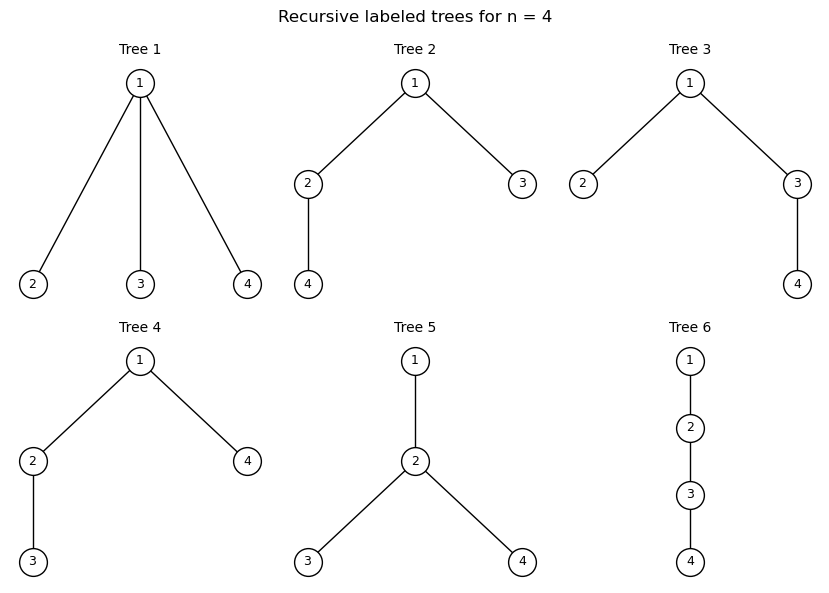

Test 2 — Number of trees for n = 10
Generated: 362880
Expected : 362880



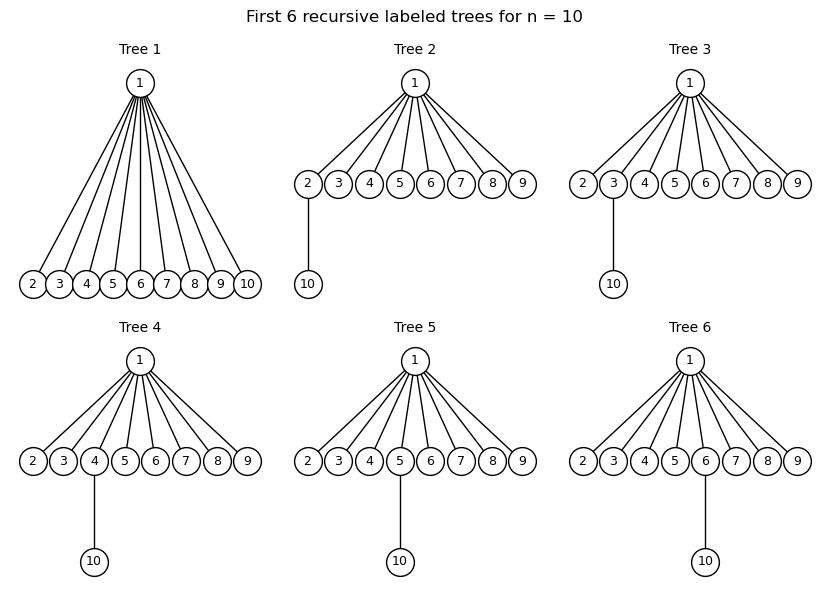

Test 3 — Before swap
1: [2, 3, 4]
2: []
3: []
4: []


C:\Users\anton\AppData\Local\Temp\ipykernel_6052\207974718.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


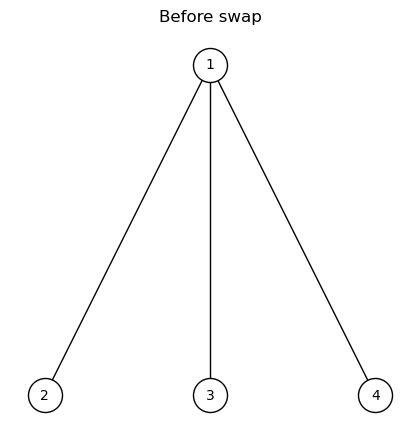

Test 3 — After swap
1: [4, 3, 2]
2: []
3: []
4: []


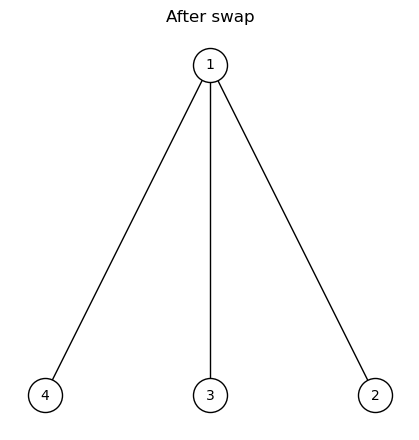

In [2]:
import math
import networkx as nx
import matplotlib.pyplot as plt


def generate_recursive_trees(n):
    """
    Generate all recursive labeled trees on nodes 1..n.

    Representation:
        parents[node] = parent of node
        parents[1] = None
    """
    if n < 1:
        return []

    trees = []
    parents = {1: None}

    def backtrack(i):
        if i > n:
            trees.append(parents.copy())
            return

        for p in range(1, i):
            parents[i] = p
            backtrack(i + 1)

    backtrack(2)
    return trees


def parents_to_children(parents, n):
    """
    Convert parent representation into ordered children lists.
    """
    children = {i: [] for i in range(1, n + 1)}

    for node in range(2, n + 1):
        parent = parents[node]
        children[parent].append(node)

    return children


def children_to_digraph(children):
    """
    Convert ordered children dictionary into a NetworkX directed graph.
    """
    G = nx.DiGraph()

    for parent, child_list in children.items():
        G.add_node(parent)
        for child in child_list:
            G.add_edge(parent, child)

    return G


def hierarchical_positions(children, root=1, x=0, y=0, dx=1.2, pos=None):
    """
    Compute hierarchical positions for a tree while preserving child order.
    """
    if pos is None:
        pos = {}

    pos[root] = (x, y)
    child_list = children[root]

    if not child_list:
        return pos

    start_x = x - dx * (len(child_list) - 1) / 2

    for i, child in enumerate(child_list):
        child_x = start_x + i * dx
        hierarchical_positions(
            children,
            root=child,
            x=child_x,
            y=y - 1,
            dx=dx / 1.5,
            pos=pos
        )

    return pos


def plot_trees_compact(trees, n, cols=3, main_title=None):
    """
    Plot several trees in a compact grid.
    """
    if not trees:
        print("No trees to display.")
        return

    rows = math.ceil(len(trees) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(2.8 * cols, 3.0 * rows))

    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1:
        axes = list(axes)
    else:
        axes = axes.flatten()

    for i, parents in enumerate(trees):
        children = parents_to_children(parents, n)
        G = children_to_digraph(children)
        pos = hierarchical_positions(children, root=1, dx=1.2)

        nx.draw(
            G,
            pos,
            ax=axes[i],
            with_labels=True,
            node_size=400,
            node_color="white",
            edgecolors="black",
            arrows=False,
            font_size=9
        )

        axes[i].set_title(f"Tree {i + 1}", fontsize=10)
        axes[i].axis("off")

    for j in range(len(trees), len(axes)):
        axes[j].axis("off")

    if main_title:
        fig.suptitle(main_title, fontsize=12)

    plt.tight_layout()
    plt.show()


def swap_children(children, parent, a, b):
    """
    Swap the order of two children under the same parent.
    """
    if parent not in children:
        raise ValueError("Parent not found.")

    if a not in children[parent] or b not in children[parent]:
        raise ValueError("Both nodes must be children of the given parent.")

    i = children[parent].index(a)
    j = children[parent].index(b)
    children[parent][i], children[parent][j] = children[parent][j], children[parent][i]


def plot_one_tree(children, title="Tree"):
    """
    Plot a single tree.
    """
    G = children_to_digraph(children)
    pos = hierarchical_positions(children, root=1, dx=1.5)

    plt.figure(figsize=(4, 4))
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=600,
        node_color="white",
        edgecolors="black",
        arrows=False,
        font_size=10
    )
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def print_children(children):
    """
    Print ordered children lists.
    """
    for parent in sorted(children):
        print(f"{parent}: {children[parent]}")


# =========================================================
# TESTS
# =========================================================

# Test 1: generate trees for n = 4
n = 4
trees_n4 = generate_recursive_trees(n)

print("Test 1 — Number of trees for n = 4")
print("Generated:", len(trees_n4))
print("Expected :", math.factorial(n - 1))
print()

# Plot the 6 trees for n = 4 in a compact layout
plot_trees_compact(
    trees_n4,
    n=4,
    cols=3,
    main_title="Recursive labeled trees for n = 4"
)

# Test 2: generate trees for n = 10
n = 10
trees_n10 = generate_recursive_trees(n)

print("Test 2 — Number of trees for n = 10")
print("Generated:", len(trees_n10))
print("Expected :", math.factorial(n - 1))
print()

# Plot only the first 6 trees for n = 10
plot_trees_compact(
    trees_n10[:6],
    n=10,
    cols=3,
    main_title="First 6 recursive labeled trees for n = 10"
)

# Test 3: swap two children
parents = {1: None, 2: 1, 3: 1, 4: 1}
children = parents_to_children(parents, 4)

print("Test 3 — Before swap")
print_children(children)
plot_one_tree(children, title="Before swap")

swap_children(children, parent=1, a=2, b=4)

print("Test 3 — After swap")
print_children(children)
plot_one_tree(children, title="After swap")